In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\Hp\OneDrive\Desktop\final year b.tech\ecommerce-data-analysis\raw_data.csv")
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [4]:
# Remove missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Convert date
df['order_date'] = pd.to_datetime(df['order_date'])

# Create revenue column
df['revenue'] = df['quantity'] * df['unit_price'] * (1 - df['discount'])

# Extract month
df['month'] = df['order_date'].dt.month

df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,month
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.1960,1
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.1038,1
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.3496,1
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.9030,1
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.5645,1


In [5]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5000 non-null   int64         
 1   order_date        5000 non-null   datetime64[ns]
 2   customer_id       5000 non-null   int64         
 3   product_category  5000 non-null   object        
 4   region            5000 non-null   object        
 5   quantity          5000 non-null   int64         
 6   unit_price        5000 non-null   float64       
 7   discount          5000 non-null   float64       
 8   payment_method    5000 non-null   object        
 9   delivery_days     5000 non-null   int64         
 10  customer_rating   5000 non-null   float64       
 11  revenue           5000 non-null   float64       
 12  month             5000 non-null   int32         
dtypes: datetime64[ns](1), float64(4), int32(1), int64(4), object(3)
memory usage: 

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue', 'month'],
      dtype='object')

In [6]:
print("Total Revenue:", df['revenue'].sum())

Total Revenue: 5109775.884


In [7]:
df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)

product_category
Electronics    1.829899e+06
Clothing       1.531932e+06
Home           9.820840e+05
Beauty         7.658610e+05
Name: revenue, dtype: float64

In [8]:
df.groupby('region')['revenue'].sum().sort_values(ascending=False)

region
West     1.345582e+06
North    1.281509e+06
South    1.246641e+06
East     1.236044e+06
Name: revenue, dtype: float64

In [9]:
monthly_sales = df.groupby('month')['revenue'].sum()
monthly_sales

month
1     426374.9170
2     413890.2349
3     425050.5602
4     398715.1314
5     479772.6548
6     442941.5503
7     440570.8038
8     460874.8096
9     402368.1195
10    407873.1832
11    410657.8347
12    400686.0846
Name: revenue, dtype: float64

In [10]:
df.groupby('customer_id')['revenue'].sum().sort_values(ascending=False).head()

customer_id
1663    17680.7023
1955    16265.1461
1675    15036.4703
1276    15023.7085
1647    14894.9657
Name: revenue, dtype: float64

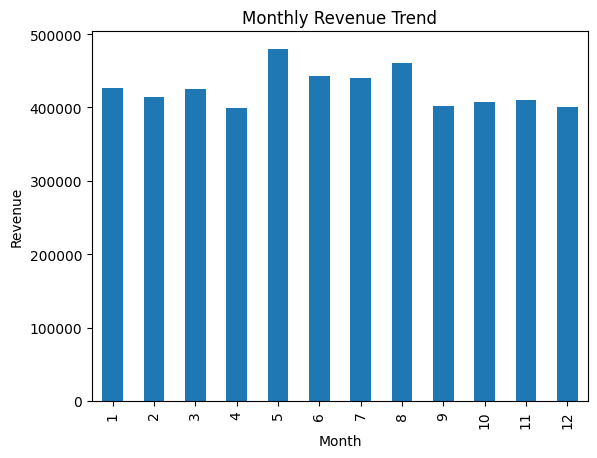

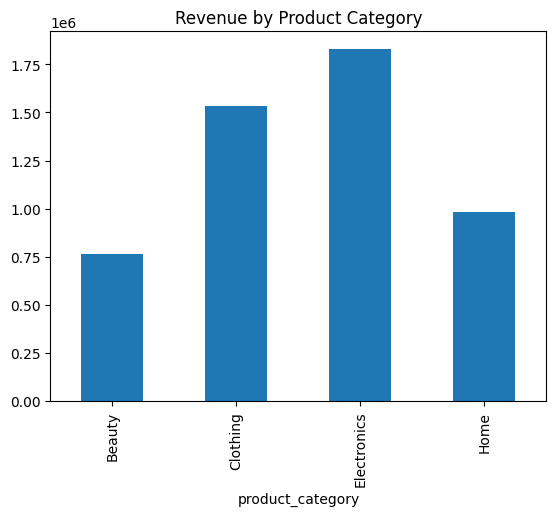

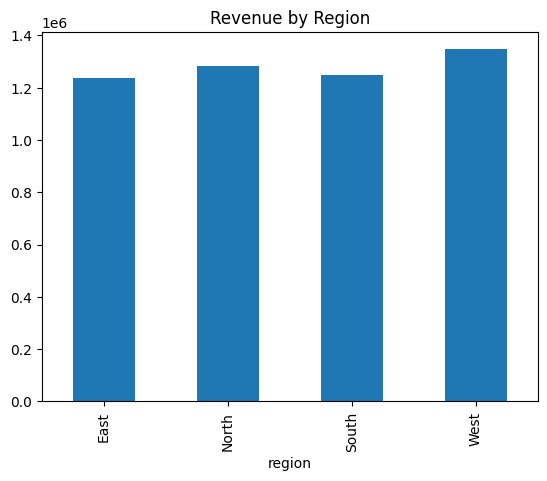

In [11]:
# Monthly Revenue
monthly_sales.plot(kind='bar')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

# Category Revenue
df.groupby('product_category')['revenue'].sum().plot(kind='bar')
plt.title("Revenue by Product Category")
plt.show()

# Region Revenue
df.groupby('region')['revenue'].sum().plot(kind='bar')
plt.title("Revenue by Region")
plt.show()

## Key Insights

- The business generates significant revenue from a few top product categories.
- Certain regions contribute more to overall sales performance.
- Monthly revenue shows variation, indicating seasonal demand patterns.
- A small percentage of customers contribute a large share of revenue.
- Discounts influence purchasing behavior and overall revenue.

In [12]:
df.to_csv(r"C:\Users\Hp\OneDrive\Desktop\final year b.tech\ecommerce-data-analysis\raw_data.csv", index=False)